In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jyr0hJYNK8EbOiN20vOR")
project = rf.workspace("new-workspace-qqoqn").project("pharyngitis-classification")
version = project.version(1)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pharyngitis-Classification-1 in folder:: 100%|██████████| 373/373 [00:00<00:00, 12403.08it/s]


In [3]:
!pip install ultralytics -q
from ultralytics import YOLO

models = YOLO("yolov8s-cls.pt")

results= models.train(
    data=dataset.location,
    epochs=50,
    imgsz=640,
    name = "throat disease classification"
)

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pharyngitis-Classification-1, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=throat disease classification, nbs=64, nms=False, opset=None, optimize=Fa

In [7]:
metrics = models.val(
    data=dataset.location,
    split="test"
)

test_accuracy = metrics.top1
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/Pharyngitis-Classification-1/train... found 253 images in 2 classes ✅ 
val: /content/Pharyngitis-Classification-1/valid... found 72 images in 2 classes ✅ 
test: /content/Pharyngitis-Classification-1/test... found 37 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 235.4±84.5 MB/s, size: 5.0 KB)
test: Scanning /content/Pharyngitis-Classification-1/test... 37 images, 0 corrupt: 100% ━━━━━━━━━━━━ 37/37 9.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.9s
                   all      0.892          1
Speed: 8.6ms preprocess, 5.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-3
Test Accuracy: 89.19%


Results saved to: /content/runs/classify/throat disease classification


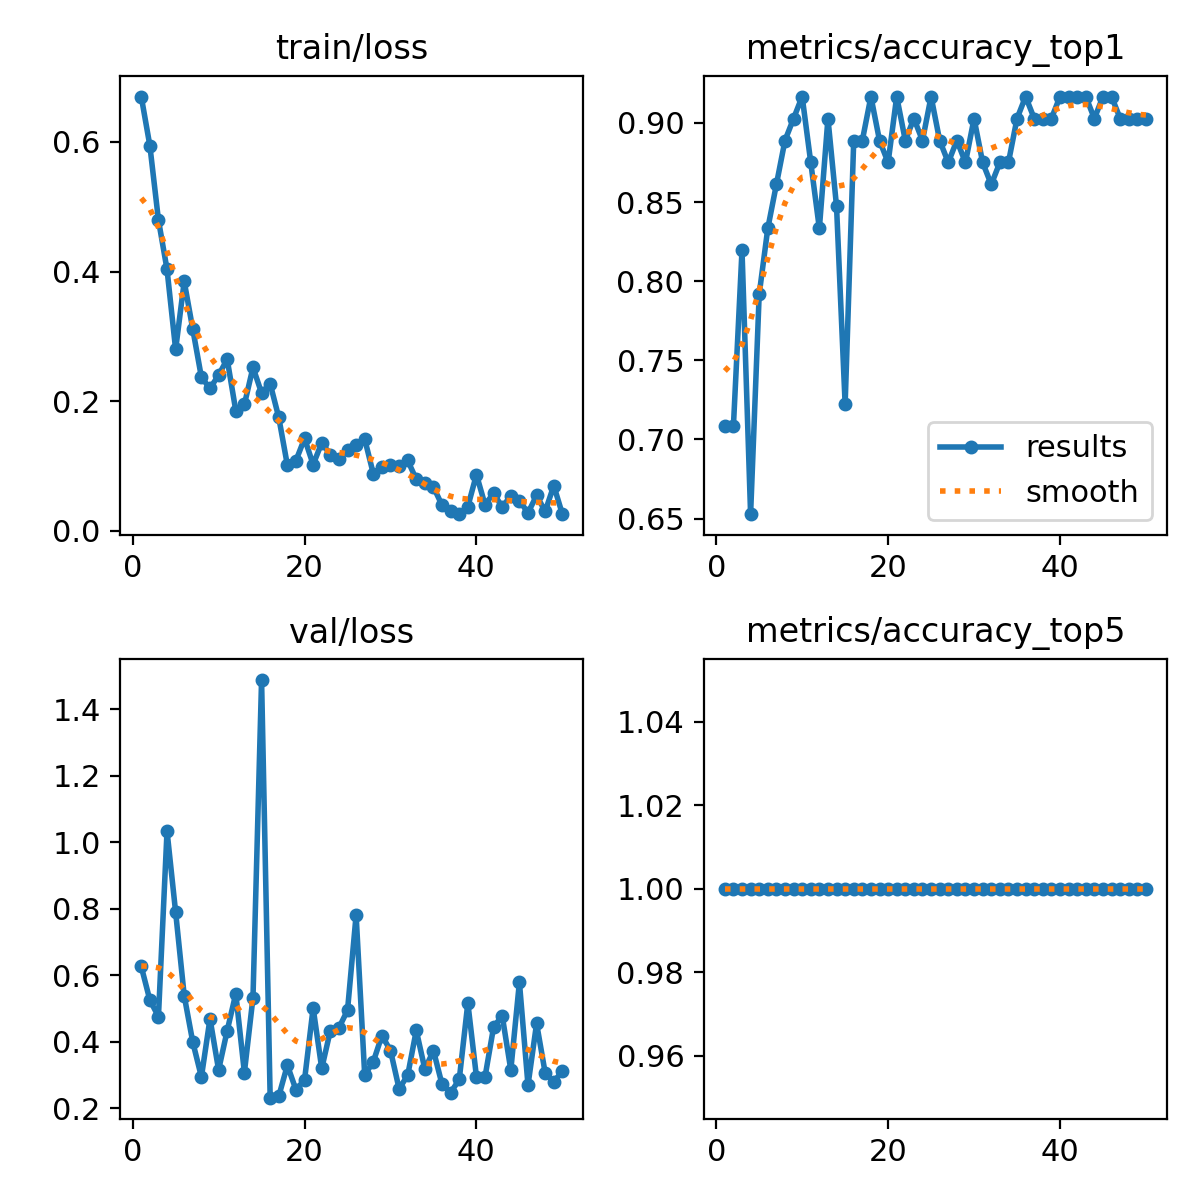

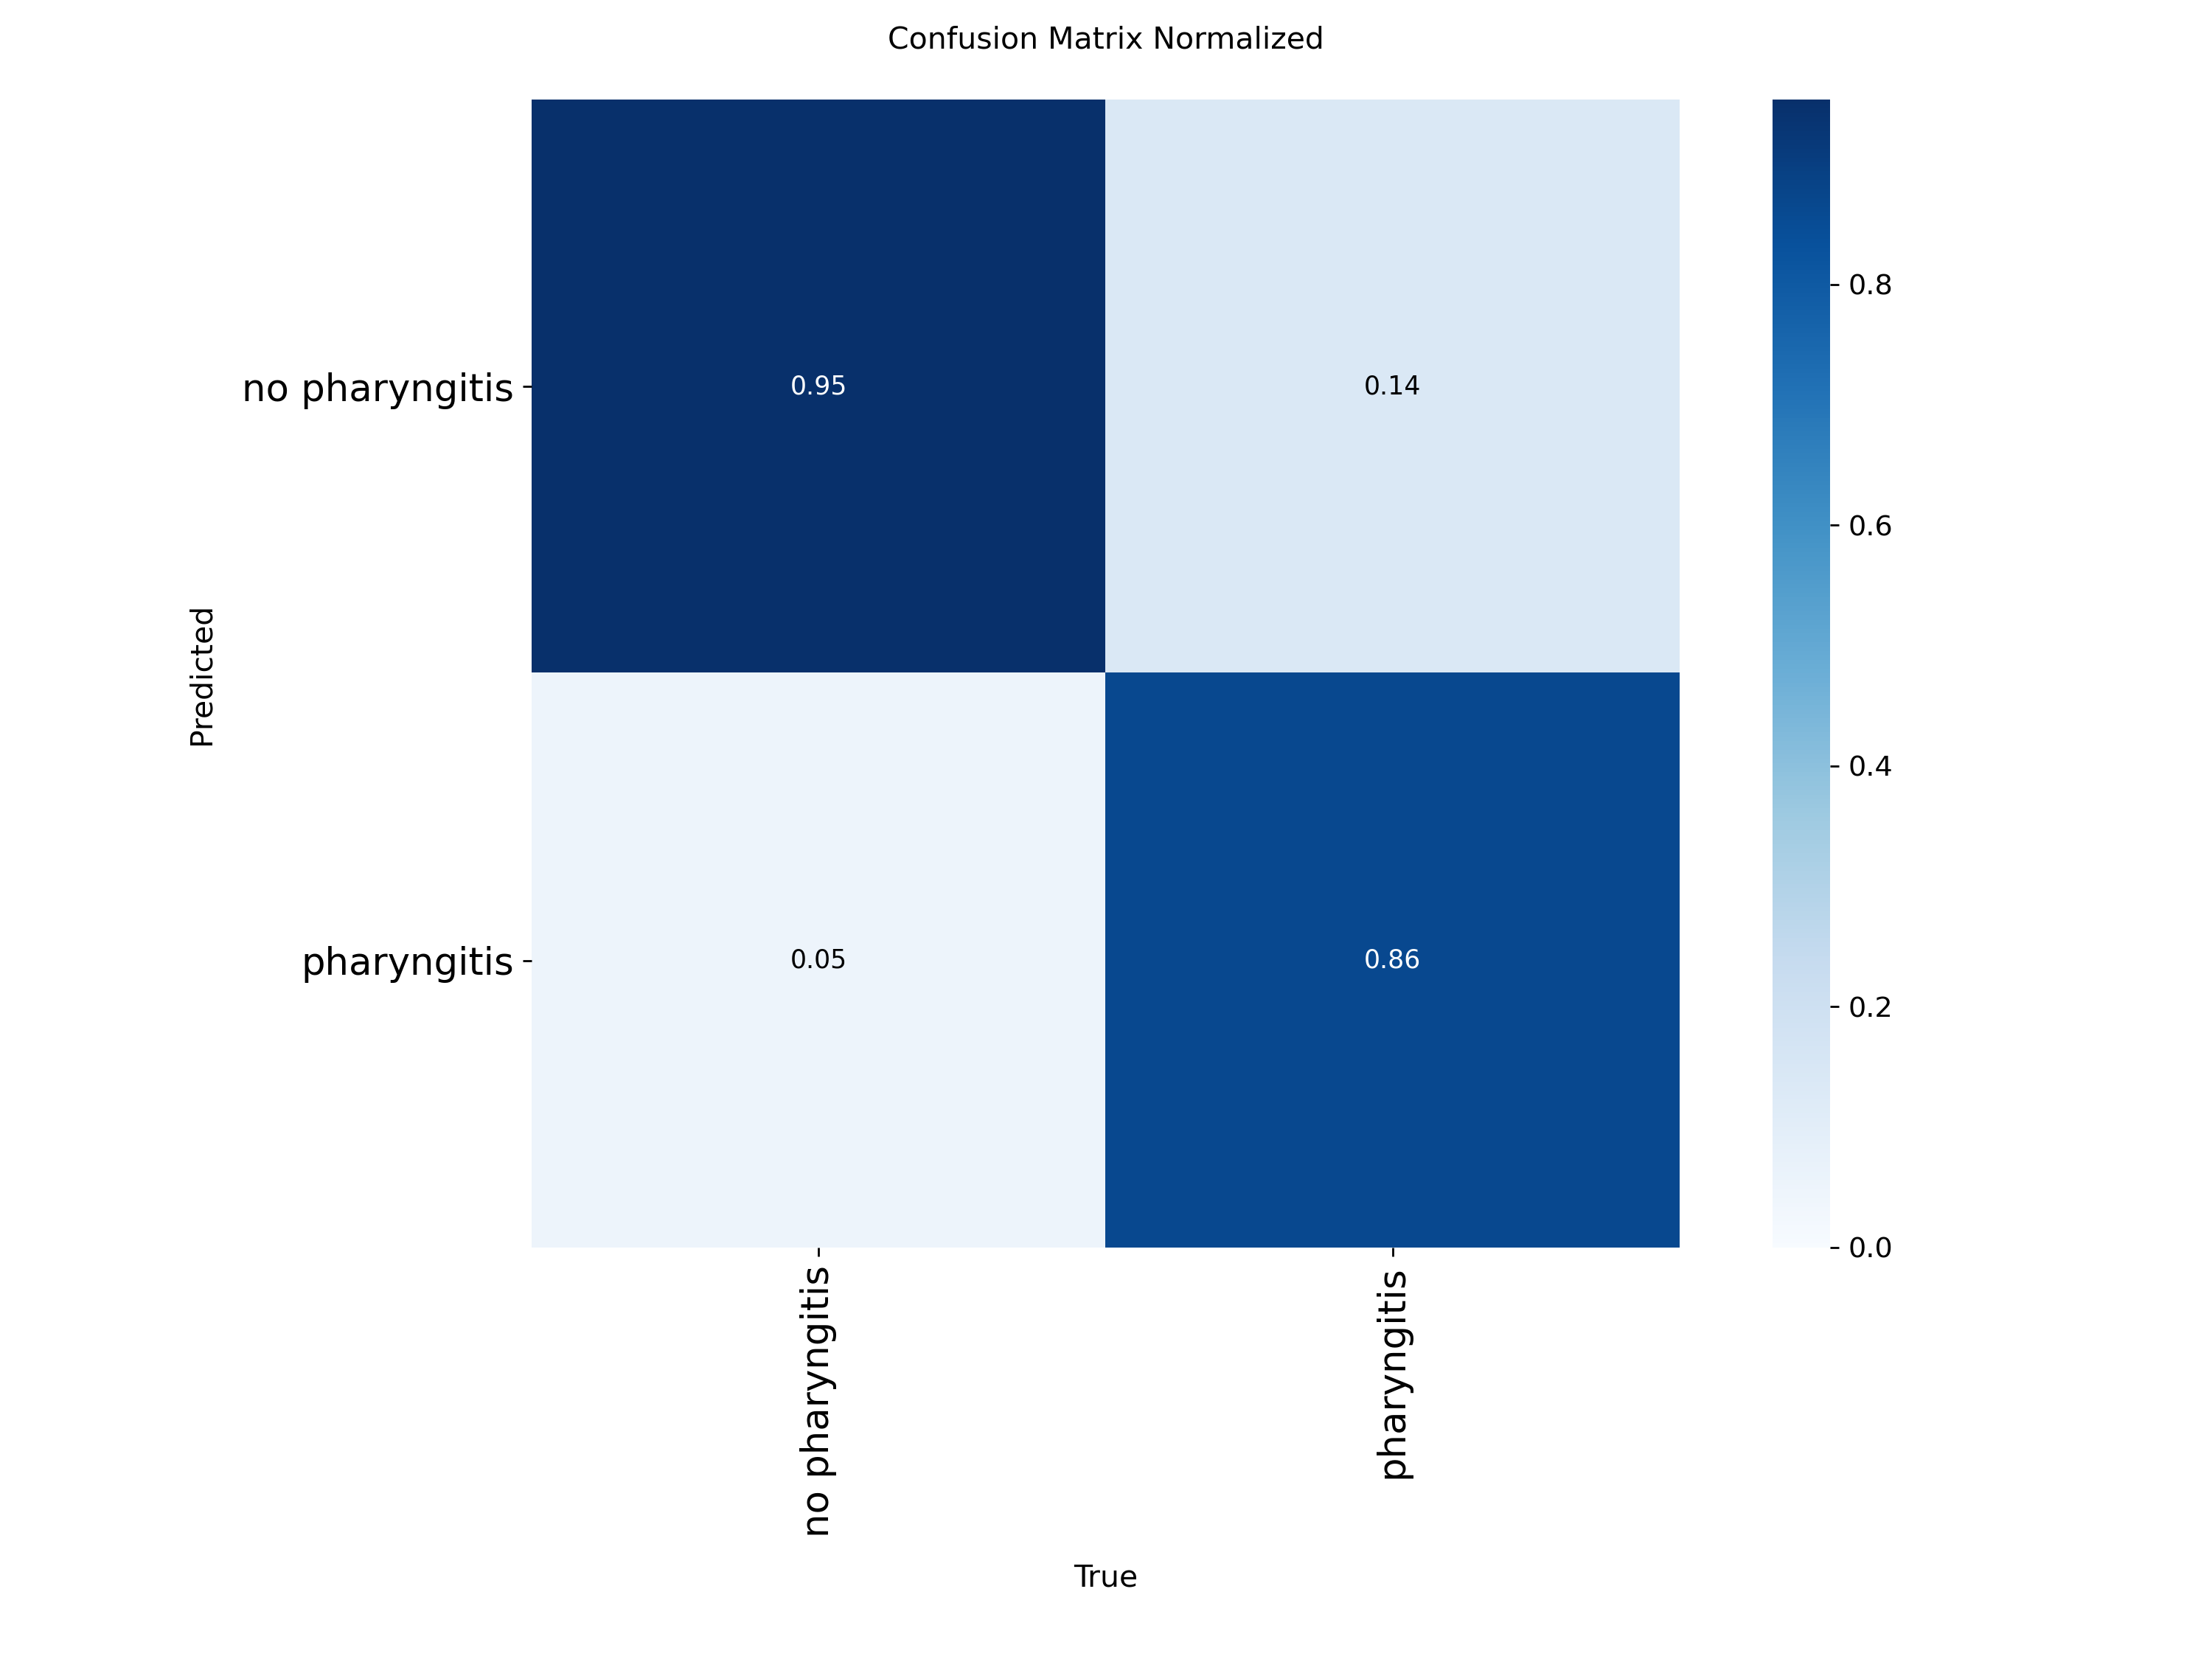

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ---------------------------
# 1. Ultralytics tells you exactly where results were saved
# ---------------------------
save_dir = results.save_dir
print(f"Results saved to: {save_dir}")

# ---------------------------
# 2. View the auto-generated graphs directly (no need to recreate them)
# ---------------------------
display(Image(f"{save_dir}/results.png"))
display(Image(f"{save_dir}/confusion_matrix_normalized.png"))